In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [ ]:
df = pd.read_csv('yield_prediction_dataset.csv')

# Drop unnamed/empty columns if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Check missing values & types
print("\nData Info:")
df.info()

Dataset Shape: (1625, 13)

First 5 rows:
  field_id date_of_image   latitude  longitude      NDVI     GNDVI      NDWI  \
0  Field_1    01-01-2023  22.625231  88.497925  0.060190  0.084801 -0.084801   
1  Field_1    16-01-2023  22.625231  88.497925  0.213957  0.222009 -0.222009   
2  Field_1    31-01-2023  22.625231  88.497925  0.403306  0.431204 -0.431204   
3  Field_1    15-02-2023  22.625231  88.497925  0.418187  0.444132 -0.444132   
4  Field_1    03-02-2023  22.625231  88.497925  0.375138  0.387985 -0.387985   

       SAVI  soil_moisture  temperature   rainfall crop_type      yield  
0  0.090280      46.119353     9.884229   1.662354      Rice  40.218031  
1  0.320896      37.542525    13.967073   8.446302      Rice  30.870338  
2  0.604837      24.926279    13.590147   3.862833      Rice  45.330050  
3  0.627144      24.114157    12.343355  16.623542      Rice  49.711781  
4  0.562591      27.420927    11.007707   9.496210      Rice  34.542646  

Data Info:
<class 'pandas.core.fr

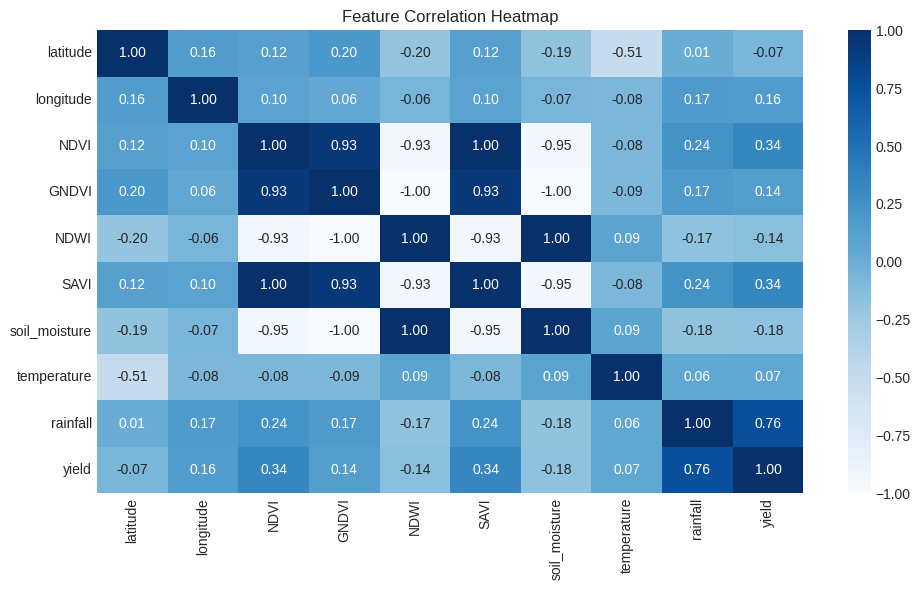

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

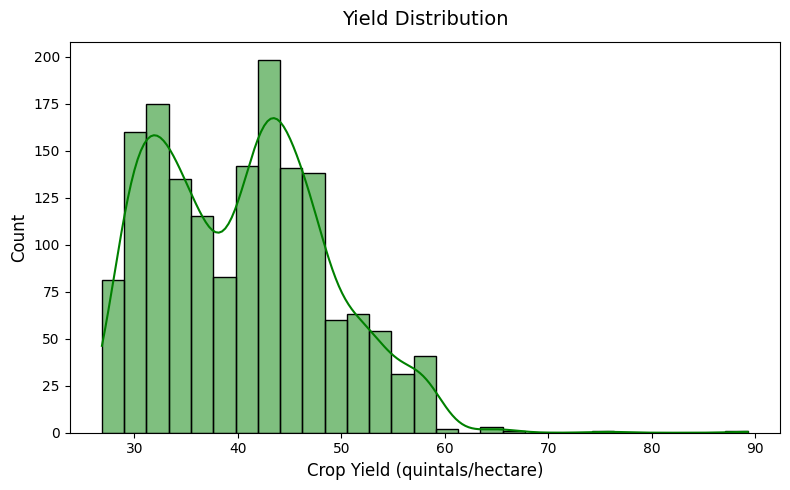

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('yield_prediction_dataset.csv')
# Drop unnamed/empty columns if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

plt.figure(figsize=(8, 5))
sns.histplot(df['yield'], kde=True, color='green')
plt.title('Yield Distribution', fontsize=14, pad=12)
plt.xlabel('Crop Yield (quintals/hectare)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('yield_distribution.png', dpi=300)
plt.show()

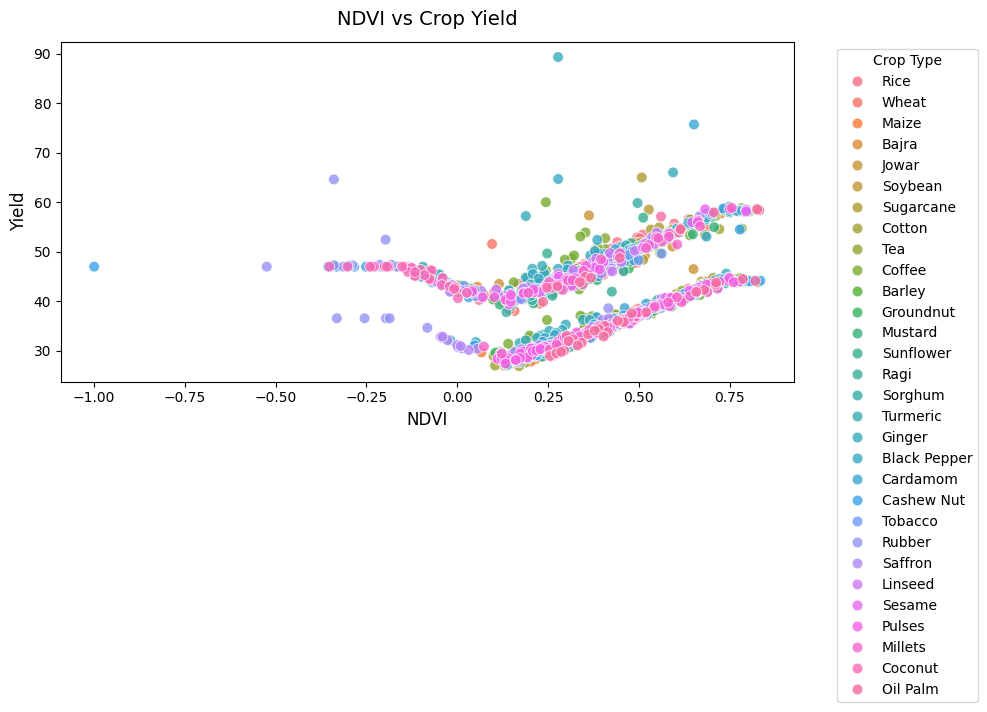

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='NDVI', y='yield', hue='crop_type', alpha=0.8, s=60)
plt.title('NDVI vs Crop Yield', fontsize=14, pad=12)
plt.xlabel('NDVI', fontsize=12)
plt.ylabel('Yield', fontsize=12)
# Move legend outside to prevent cluttering the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Crop Type', frameon=True)
plt.tight_layout()
plt.savefig('ndvi_vs_yield.png', dpi=300)
plt.show()

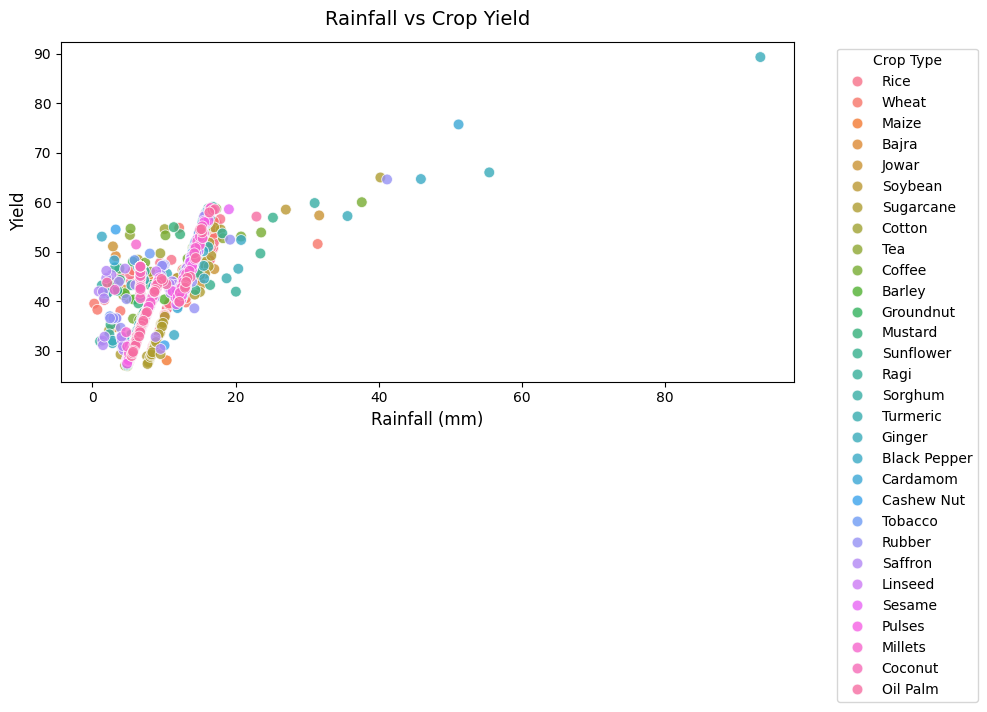

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rainfall', y='yield', hue='crop_type', alpha=0.8, s=60)
plt.title('Rainfall vs Crop Yield', fontsize=14, pad=12)
plt.xlabel('Rainfall (mm)', fontsize=12)
plt.ylabel('Yield', fontsize=12)
# Move legend outside to prevent cluttering the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Crop Type', frameon=True)
plt.tight_layout()
plt.savefig('rainfall_vs_yield.png', dpi=300)
plt.show()

In [ ]:
# Drop identifier and date columns as they do not generalise across new spatial locations
X = df.drop(columns=['field_id', 'date_of_image', 'yield'])
y = df['yield']

num_cols = ['latitude', 'longitude', 'NDVI', 'GNDVI', 'NDWI', 'SAVI', 'soil_moisture', 'temperature', 'rainfall']
cat_cols = ['crop_type']

# Column Transformer: StandardScaler for numeric features, OneHotEncoder for categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit & transform features
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Save preprocessor for API usage
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [ ]:
models = {
    'Stochastic Gradient Descent (SGD)': SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    'Ordinary Least Squares (OLS)': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_y_test, preds)
    results[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'model': model}
    print(f"[{name}] MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# Determine best model based on minimum MSE
best_model_name = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_model_name]['model']
print(f"\n---> BEST PERFORMING MODEL: {best_model_name}")

# Save Best Model
joblib.dump(best_model, 'best_model.pkl')

[Stochastic Gradient Descent (SGD)] MSE: 49.0070 | RMSE: 7.0005 | R2: 0.3678
[Ordinary Least Squares (OLS)] MSE: 21.0574 | RMSE: 4.5888 | R2: 0.7284
[Decision Tree] MSE: 9.3992 | RMSE: 3.0658 | R2: 0.8788
[Random Forest] MSE: 6.1966 | RMSE: 2.4893 | R2: 0.9201

---> BEST PERFORMING MODEL: Random Forest


['best_model.pkl']

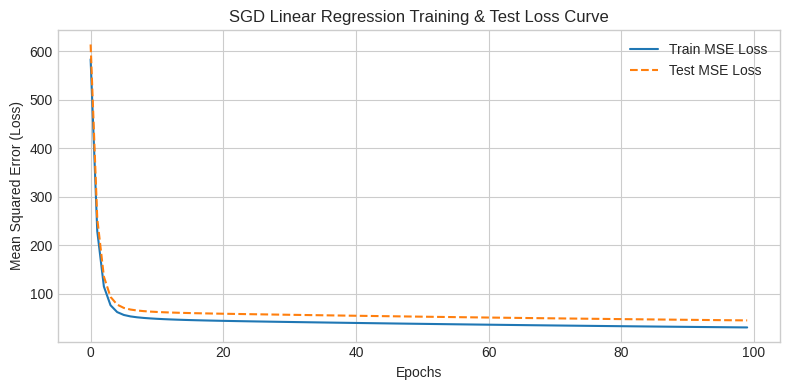

In [ ]:
sgd_iter = SGDRegressor(learning_rate='constant', eta0=0.01, random_state=42)
epochs = 100
train_losses, test_losses = [], []

for epoch in range(epochs):
    sgd_iter.partial_fit(X_train_scaled, y_train)
    train_pred = sgd_iter.predict(X_train_scaled)
    test_pred = sgd_iter.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_y_test, test_pred))

# Plot Epoch Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE Loss')
plt.plot(test_losses, label='Test MSE Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.title('SGD Linear Regression Training & Test Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('sgd_loss_curve.png')
plt.show()

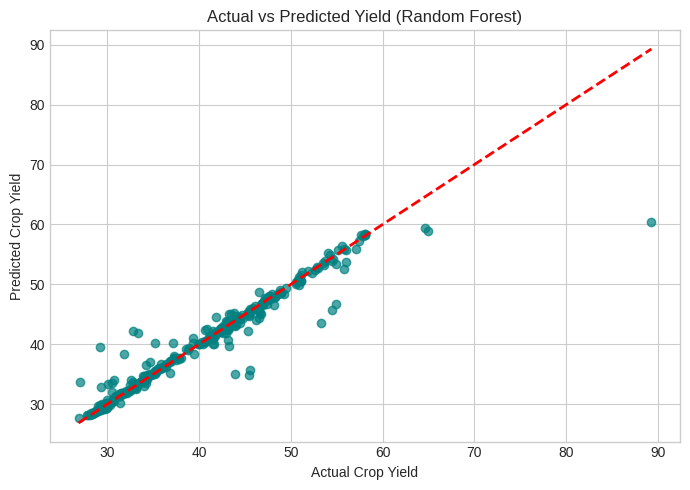

In [ ]:
plt.figure(figsize=(7, 5))
best_preds = best_model.predict(X_test_scaled)
plt.scatter(y_y_test, best_preds, alpha=0.7, color='teal')
plt.plot([y_y_test.min(), y_y_test.max()], [y_y_test.min(), y_y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Crop Yield')
plt.ylabel('Predicted Crop Yield')
plt.title(f'Actual vs Predicted Yield ({best_model_name})')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

In [ ]:
sample_data = X_test.iloc[[0]]
sample_scaled = preprocessor.transform(sample_data)
single_pred = best_model.predict(sample_scaled)[0]

print("\n--- SAMPLE ROW PREDICTION ---")
print("Input Sample Features:\n", sample_data.to_dict(orient='records')[0])
print(f"Actual Yield: {y_y_test.iloc[0]:.2f}")
print(f"Predicted Yield: {single_pred:.2f}")


--- SAMPLE ROW PREDICTION ---
Input Sample Features:
 {'latitude': 23.54870209, 'longitude': 77.3613415, 'NDVI': 0.669679027, 'GNDVI': 0.574558331, 'NDWI': -0.574558331, 'SAVI': 1.004380151, 'soil_moisture': 14.88556346, 'temperature': 11.99251511, 'rainfall': 8.867770603, 'crop_type': 'Maize'}
Actual Yield: 42.94
Predicted Yield: 42.98
